# 201 -- BCK_44 NB Full Analysis from K-Sweep

This notebook mirrors the "sweep -> fixed-K full analysis" pattern used by notebook 14 for notebook 13.

Workflow:
1. Choose `SELECT_K` from the BCK_44 sweep.
2. Automatically pick the best seed run for that K (or override manually).
3. Run full analysis and save figure panels (`fig1`..`fig10`) to `reports/`.
4. Generate a markdown report and optional PDF.


In [47]:
from pathlib import Path
import sys


def _find_repo_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for path in candidates:
        if (path / 'pyproject.toml').exists() and (path / 'src' / 'cytof_archetypes').exists():
            return path
    fallback = Path('/Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv')
    if (fallback / 'src' / 'cytof_archetypes').exists():
        return fallback
    raise RuntimeError('Could not locate repository root')


REPO_ROOT = _find_repo_root()
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))

print('Repo root:', REPO_ROOT)



Repo root: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv


In [49]:
import json
import re
import warnings
import subprocess

import numpy as np
import h5py
import pandas as pd
import scanpy as sc
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from scipy.stats import pearsonr, spearmanr

warnings.filterwarnings('ignore')

matplotlib.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.dpi': 140,
    'savefig.dpi': 220,
    'savefig.bbox': 'tight',
})

# ------------------------- User Controls -------------------------
SELECT_K = 7               # choose K from sweep (4,5,6,7,8)
SELECT_SEED = 'best'       # 'best' or integer seed (e.g., 42)
FORCE_RECOMPUTE_UMAP = False
MAX_CELLS_FOR_PLOTTING = 100_000
TOP_GENES_PER_ARCH = 12

SWEEP_RUNS_DIR = REPO_ROOT / 'outputs' / 'bck44_scrna_nb_k_sweep' / 'runs'
H5AD_PATH = REPO_ROOT / 'data' / 'bck44_scrna_hvg_counts.h5ad'
H5SEURAT_SIGNATURE_PATH = Path('/Users/ronguy/Dropbox/Work/CyTOF/SingleCell/MOme_MPGMP/MultiOme/Output/BCK_44.RNA.SCT_UCell_tumor.h5seurat')
SIGNATURE_REGEX = r'(_UCell$)|(^sig_)'
MAX_SIGNATURES_HEATMAP = 24

OUT_DIR = REPO_ROOT / f'reports/bck44_nb_k{SELECT_K}'
FIG_DIR = OUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('Sweep runs:', SWEEP_RUNS_DIR)
print('h5ad path :', H5AD_PATH)
print('sig file :', H5SEURAT_SIGNATURE_PATH)
print('Report dir:', OUT_DIR)



Sweep runs: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/bck44_scrna_nb_k_sweep/runs
h5ad path : /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/data/bck44_scrna_hvg_counts.h5ad
sig file : /Users/ronguy/Dropbox/Work/CyTOF/SingleCell/MOme_MPGMP/MultiOme/Output/BCK_44.RNA.SCT_UCell_tumor.h5seurat
Report dir: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/reports/bck44_nb_k7


In [50]:
# Resolve selected run from sweep outputs
assert SWEEP_RUNS_DIR.exists(), f'Missing sweep run directory: {SWEEP_RUNS_DIR}'

run_rows = []
pat = re.compile(r'^k(?P<k>\d+)_seed(?P<seed>\d+)$')

for p in sorted(SWEEP_RUNS_DIR.iterdir()):
    if not p.is_dir():
        continue
    m = pat.match(p.name)
    if m is None:
        continue
    k = int(m.group('k'))
    seed = int(m.group('seed'))

    hist_path = p / 'training_log.csv'
    if not hist_path.exists():
        continue
    hist = pd.read_csv(hist_path)

    if 'val_recon' in hist.columns:
        best_val = float(hist['val_recon'].min())
        best_col = 'val_recon'
    elif 'val_nll' in hist.columns:
        best_val = float(hist['val_nll'].min())
        best_col = 'val_nll'
    else:
        best_val = float(hist['val_loss'].min())
        best_col = 'val_loss'

    run_rows.append({
        'k': k,
        'seed': seed,
        'run_dir': p,
        'best_val': best_val,
        'best_col': best_col,
        'n_epochs': int(len(hist)),
    })

runs_df = pd.DataFrame(run_rows)
if len(runs_df) == 0:
    raise RuntimeError('No completed runs found in sweep directory.')

runs_k = runs_df[runs_df['k'] == int(SELECT_K)].copy()
if len(runs_k) == 0:
    raise RuntimeError(f'No runs found for K={SELECT_K}. Available K: {sorted(runs_df.k.unique().tolist())}')

if SELECT_SEED == 'best':
    pick = runs_k.sort_values('best_val', ascending=True).iloc[0]
else:
    seed_int = int(SELECT_SEED)
    sub = runs_k[runs_k['seed'] == seed_int]
    if len(sub) == 0:
        raise RuntimeError(f'No run found for K={SELECT_K}, seed={seed_int}')
    pick = sub.iloc[0]

RUN_DIR = Path(pick['run_dir'])
SEED = int(pick['seed'])
BEST_COL = str(pick['best_col'])

print('Selected run:', RUN_DIR)
print(f'K={SELECT_K}, seed={SEED}, best {BEST_COL}={pick.best_val:.6f}')
print('\nAll runs for selected K:')
display(runs_k.sort_values('best_val').reset_index(drop=True))



Selected run: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/bck44_scrna_nb_k_sweep/runs/k7_seed42
K=7, seed=42, best val_recon=1014.156677

All runs for selected K:


,k,seed,run_dir,best_val,best_col,n_epochs
0,7,42,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/P...,1014.156677,val_recon,595


In [51]:
# Load run artifacts + processed data
assert H5AD_PATH.exists(), f'Missing H5AD: {H5AD_PATH}'
adata = sc.read_h5ad(H5AD_PATH)
print(f'h5ad loaded: {adata.n_obs:,} cells x {adata.n_vars:,} genes')

fractions_path = RUN_DIR / 'archetypes' / 'archetype_gene_fractions.csv'
logits_path = RUN_DIR / 'archetypes' / 'archetype_logits.csv'
theta_path = RUN_DIR / 'archetypes' / 'gene_dispersion.csv'
hist_path = RUN_DIR / 'training_log.csv'
weights_all_path = RUN_DIR / 'weights' / 'cell_weights.csv'

for p in [fractions_path, logits_path, theta_path, hist_path, weights_all_path]:
    if not p.exists():
        raise FileNotFoundError(f'Missing expected artifact: {p}')

fractions = pd.read_csv(fractions_path, index_col=0)
logits = pd.read_csv(logits_path, index_col=0)
theta_df = pd.read_csv(theta_path)
hist = pd.read_csv(hist_path)
weights_all = pd.read_csv(weights_all_path)

K = fractions.shape[0]
W_COLS = [c for c in weights_all.columns if c.startswith('w_')]
assert len(W_COLS) == K, f'Expected {K} weight columns, found {len(W_COLS)}'

COMP_NAMES = [f'A{i}' for i in range(K)]
fractions.index = COMP_NAMES
logits.index = COMP_NAMES

print('Archetypes:', COMP_NAMES)
print('Training epochs:', len(hist))
print('Best val metric:', hist[BEST_COL].min())
print('Weights rows:', len(weights_all))



h5ad loaded: 352 cells x 2,000 genes
Archetypes: ['A0', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6']
Training epochs: 595
Best val metric: 1014.1566772460938
Weights rows: 352


In [52]:
# Align weights to adata and compute derived fields
if 'cell_id' in adata.obs.columns:
    adata.obs['cell_id'] = adata.obs['cell_id'].astype(str)
else:
    adata.obs['cell_id'] = adata.obs_names.astype(str)

w = weights_all.copy()
w['cell_id'] = w['cell_id'].astype(str)

obs_df = adata.obs[['cell_id']].copy()
obs_df = obs_df.reset_index().rename(columns={'index': 'obs_name'})
merged = obs_df.merge(w, on='cell_id', how='inner')

if len(merged) == 0:
    raise RuntimeError('No aligned cells between H5AD and weight table.')

W = merged[W_COLS].to_numpy(dtype=float)
merged['dominant'] = np.argmax(W, axis=1)
merged['dominant_name'] = merged['dominant'].map({i: f'A{i}' for i in range(K)})
merged['entropy'] = -(np.clip(W, 1e-12, 1.0) * np.log(np.clip(W, 1e-12, 1.0))).sum(axis=1)
merged['effective_k'] = np.exp(merged['entropy'])

# Attach per-cell fields back to adata.obs (aligned subset)
adata_sub = adata[merged['obs_name'].values].copy()
for col in ['split', 'dominant', 'dominant_name', 'entropy', 'effective_k', *W_COLS]:
    adata_sub.obs[col] = merged[col].values

print(f'Aligned cells: {adata_sub.n_obs:,} / {adata.n_obs:,}')
print('Split counts:')
print(adata_sub.obs['split'].value_counts())



Aligned cells: 352 / 352
Split counts:
split
train    246
test      53
val       53
Name: count, dtype: int64


In [53]:
# UMAP for visualization (on log1p-normalized counts)
if FORCE_RECOMPUTE_UMAP or ('X_umap' not in adata_sub.obsm):
    adata_vis = adata_sub.copy()

    # Use sparse count matrix safely
    if sparse.issparse(adata_vis.X):
        X_counts = adata_vis.X.copy().astype(np.float32)
    else:
        X_counts = np.asarray(adata_vis.X, dtype=np.float32)

    adata_vis.layers['counts'] = X_counts
    sc.pp.normalize_total(adata_vis, target_sum=1e4)
    sc.pp.log1p(adata_vis)
    sc.pp.pca(adata_vis, n_comps=min(50, adata_vis.n_vars - 1))
    sc.pp.neighbors(adata_vis, n_neighbors=15, n_pcs=min(30, adata_vis.obsm['X_pca'].shape[1]))
    sc.tl.umap(adata_vis, random_state=42)

    adata_sub.obsm['X_umap'] = adata_vis.obsm['X_umap'].copy()

print('UMAP ready:', 'X_umap' in adata_sub.obsm)



UMAP ready: True


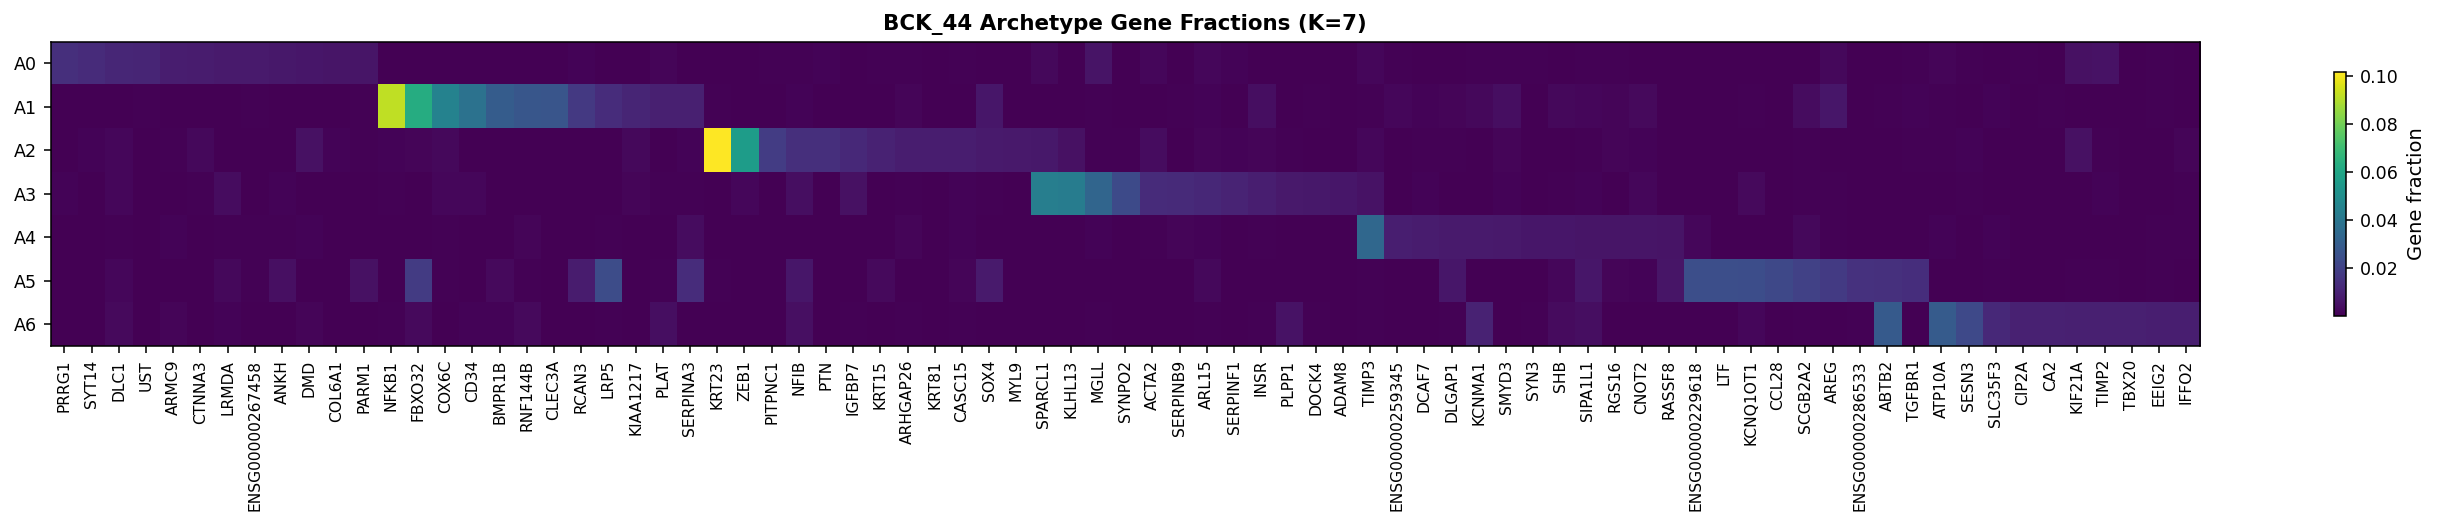

Saved fig1


In [54]:
# Figure 1: Archetype top-gene fraction heatmap
selected_genes = []
for arch in COMP_NAMES:
    top = fractions.loc[arch].sort_values(ascending=False).head(TOP_GENES_PER_ARCH).index.tolist()
    selected_genes.extend(top)

# keep order and uniqueness
seen = set()
gene_panel = []
for g in selected_genes:
    if g not in seen:
        seen.add(g)
        gene_panel.append(g)

mat = fractions[gene_panel]
fig, ax = plt.subplots(figsize=(max(10, len(gene_panel) * 0.25), max(3.5, K * 0.55)))
im = ax.imshow(mat.values, aspect='auto', cmap='viridis')
ax.set_xticks(range(len(gene_panel)))
ax.set_xticklabels(gene_panel, rotation=90, fontsize=8)
ax.set_yticks(range(K))
ax.set_yticklabels(COMP_NAMES)
ax.set_title(f'BCK_44 Archetype Gene Fractions (K={K})', fontweight='bold')
plt.colorbar(im, ax=ax, label='Gene fraction', shrink=0.8)
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig1_archetype_heatmap.png')
fig.savefig(FIG_DIR / 'fig1_archetype_heatmap.pdf')
plt.show()
print('Saved fig1')



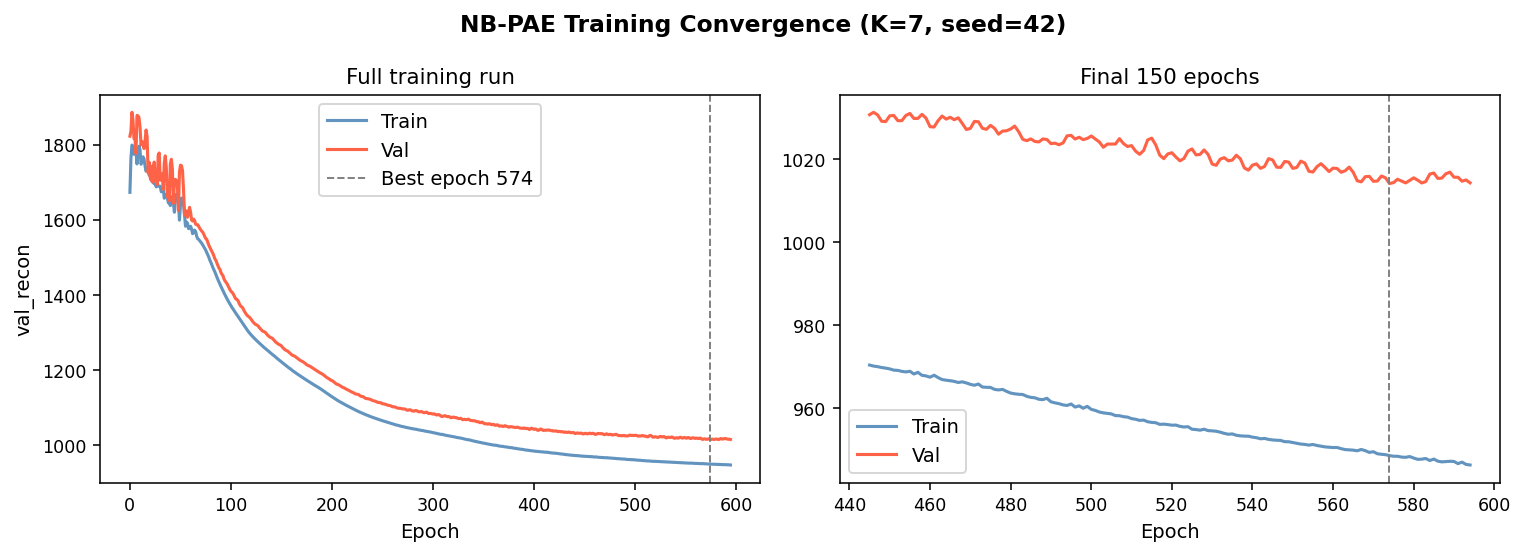

Saved fig2


In [55]:
# Figure 2: Training convergence
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
best_epoch = int(hist[BEST_COL].idxmin())

axes[0].plot(hist.index, hist['train_recon'] if 'train_recon' in hist.columns else hist['train_loss'],
             label='Train', color='steelblue', lw=1.6, alpha=0.85)
axes[0].plot(hist.index, hist[BEST_COL], label='Val', color='tomato', lw=1.6)
axes[0].axvline(best_epoch, color='gray', ls='--', lw=1, label=f'Best epoch {best_epoch}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel(BEST_COL)
axes[0].set_title('Full training run')
axes[0].legend()

n_tail = min(150, len(hist))
tail = hist.tail(n_tail)
axes[1].plot(tail.index, tail['train_recon'] if 'train_recon' in tail.columns else tail['train_loss'],
             color='steelblue', lw=1.6, alpha=0.85, label='Train')
axes[1].plot(tail.index, tail[BEST_COL], color='tomato', lw=1.6, label='Val')
axes[1].axvline(best_epoch, color='gray', ls='--', lw=1)
axes[1].set_title(f'Final {n_tail} epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()

fig.suptitle(f'NB-PAE Training Convergence (K={K}, seed={SEED})', fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig2_training_convergence.png')
fig.savefig(FIG_DIR / 'fig2_training_convergence.pdf')
plt.show()
print('Saved fig2')



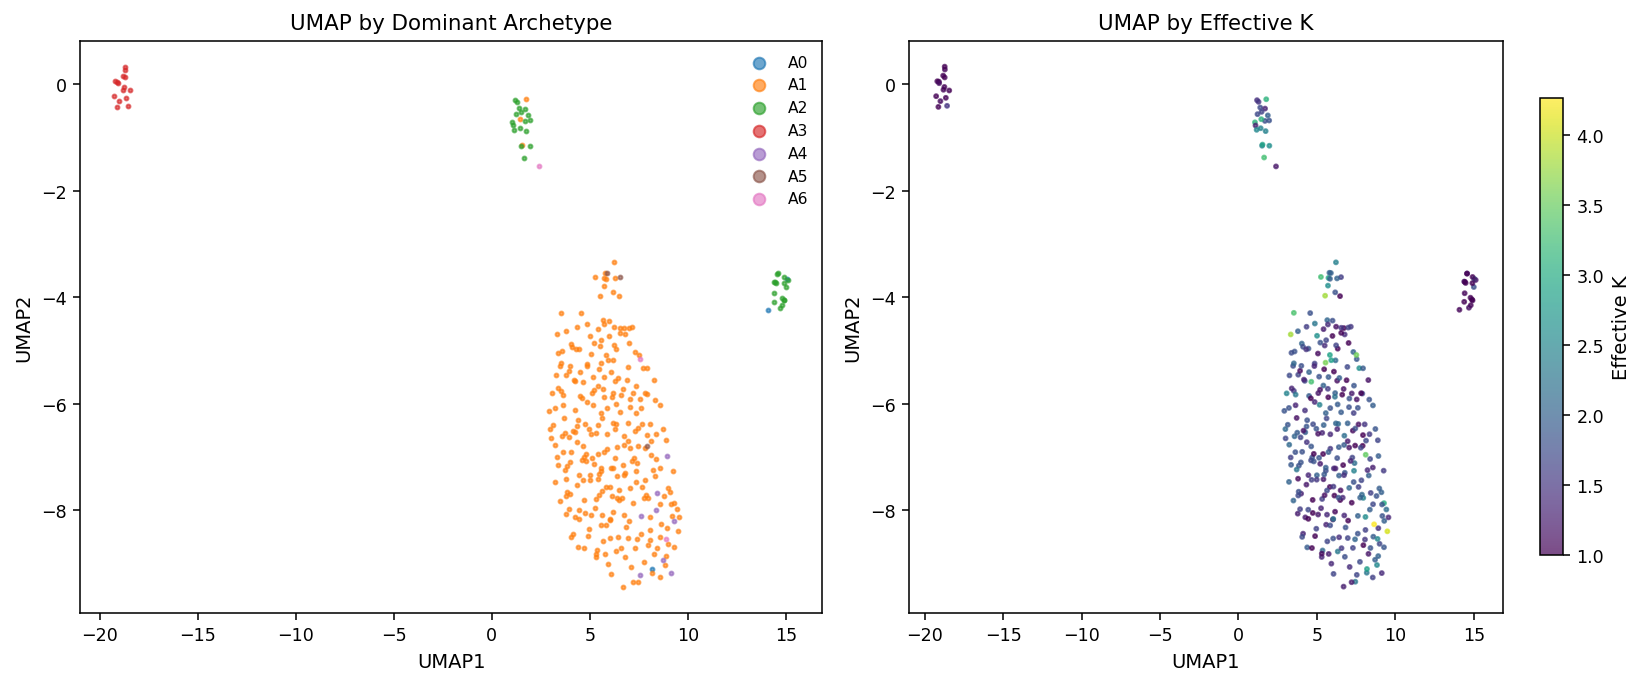

Saved fig3


In [56]:
# Figure 3: UMAP colored by dominant archetype and effective K
coords = adata_sub.obsm['X_umap']

if adata_sub.n_obs > MAX_CELLS_FOR_PLOTTING:
    rng = np.random.default_rng(42)
    idx = rng.choice(adata_sub.n_obs, size=MAX_CELLS_FOR_PLOTTING, replace=False)
else:
    idx = np.arange(adata_sub.n_obs)

coords_s = coords[idx]
dom_s = adata_sub.obs['dominant'].to_numpy()[idx]
eff_s = adata_sub.obs['effective_k'].to_numpy()[idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

palette = sns.color_palette('tab10', K)
for k_i in range(K):
    m = dom_s == k_i
    axes[0].scatter(coords_s[m, 0], coords_s[m, 1], s=4, alpha=0.65, color=palette[k_i], label=f'A{k_i}')
axes[0].set_title('UMAP by Dominant Archetype')
axes[0].set_xlabel('UMAP1')
axes[0].set_ylabel('UMAP2')
axes[0].legend(markerscale=3, fontsize=8, frameon=False)

scm = axes[1].scatter(coords_s[:, 0], coords_s[:, 1], c=eff_s, s=4, alpha=0.7, cmap='viridis')
axes[1].set_title('UMAP by Effective K')
axes[1].set_xlabel('UMAP1')
axes[1].set_ylabel('UMAP2')
plt.colorbar(scm, ax=axes[1], label='Effective K', shrink=0.8)

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig3_umap_composition.png')
fig.savefig(FIG_DIR / 'fig3_umap_composition.pdf')
plt.show()
print('Saved fig3')



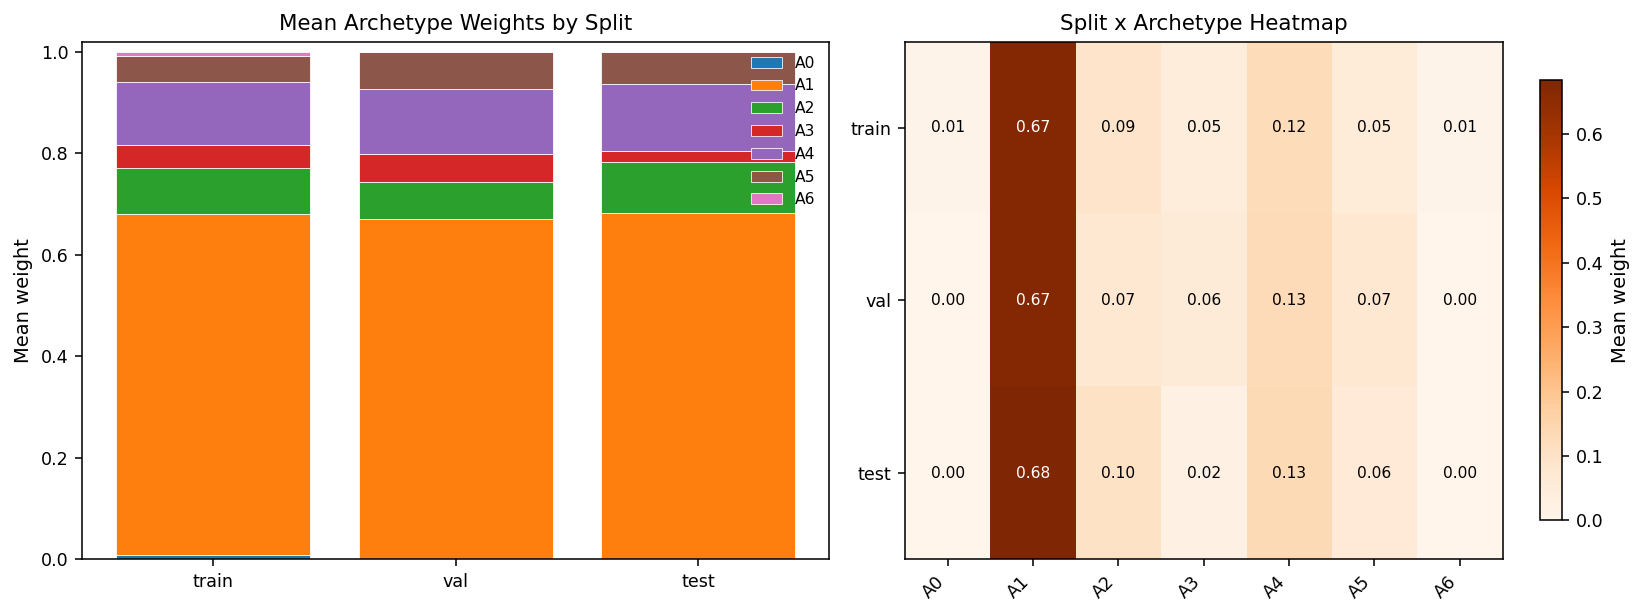

Saved fig4


In [57]:
# Figure 4: Composition by split
split_mean = adata_sub.obs.groupby('split')[W_COLS].mean().reindex(['train', 'val', 'test']).fillna(0)
split_mean.columns = COMP_NAMES

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# stacked bars
x = np.arange(len(split_mean.index))
bottom = np.zeros(len(x))
for i, comp in enumerate(COMP_NAMES):
    vals = split_mean[comp].values
    axes[0].bar(x, vals, bottom=bottom, color=palette[i], label=comp, edgecolor='white', linewidth=0.4)
    bottom += vals
axes[0].set_xticks(x)
axes[0].set_xticklabels(split_mean.index)
axes[0].set_ylim(0, 1.02)
axes[0].set_ylabel('Mean weight')
axes[0].set_title('Mean Archetype Weights by Split')
axes[0].legend(fontsize=8, frameon=False, loc='upper right')

# heatmap
im = axes[1].imshow(split_mean.values, aspect='auto', cmap='Oranges', vmin=0, vmax=max(0.35, float(split_mean.values.max())))
axes[1].set_xticks(range(K))
axes[1].set_xticklabels(COMP_NAMES, rotation=45, ha='right')
axes[1].set_yticks(range(len(split_mean.index)))
axes[1].set_yticklabels(split_mean.index)
axes[1].set_title('Split x Archetype Heatmap')
for i in range(split_mean.shape[0]):
    for j in range(split_mean.shape[1]):
        v = split_mean.iloc[i, j]
        axes[1].text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8,
                     color='white' if v > 0.22 else 'black')
plt.colorbar(im, ax=axes[1], label='Mean weight', shrink=0.85)

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig4_split_composition.png')
fig.savefig(FIG_DIR / 'fig4_split_composition.pdf')
plt.show()
print('Saved fig4')



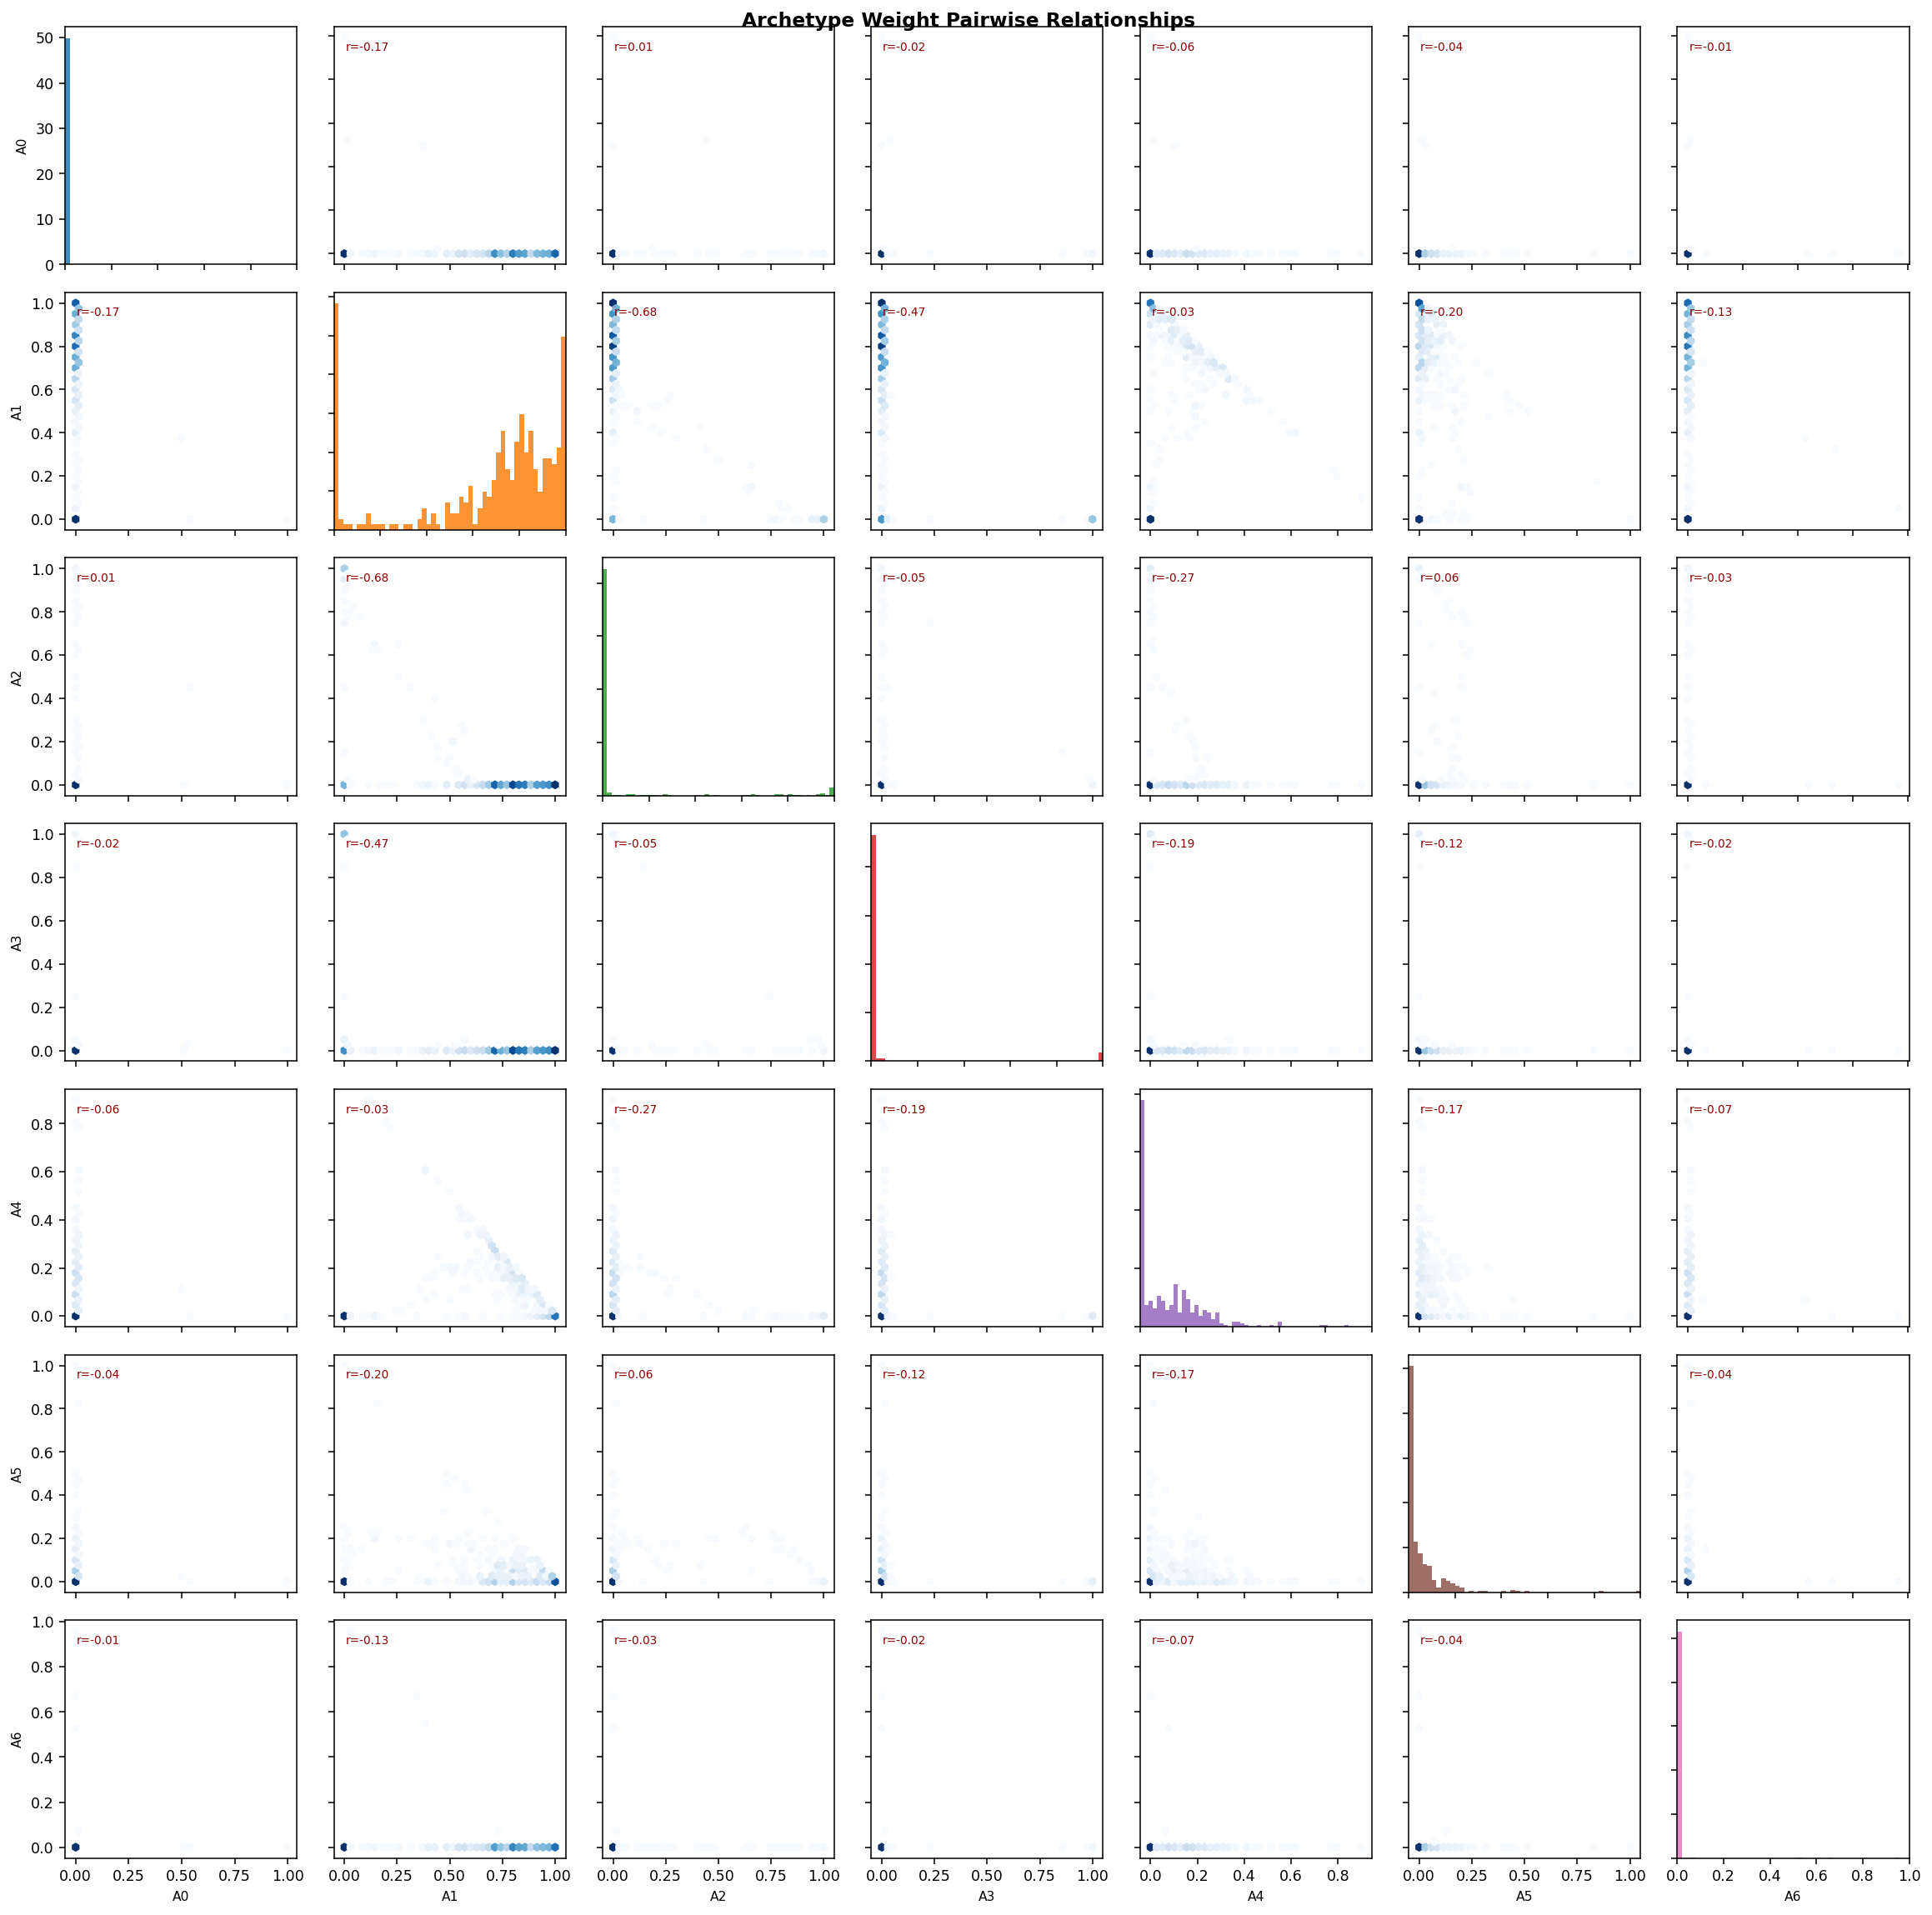

       A0     A1     A2     A3     A4     A5     A6
A0  1.000 -0.165  0.010 -0.016 -0.059 -0.042 -0.008
A1 -0.165  1.000 -0.678 -0.470 -0.032 -0.204 -0.132
A2  0.010 -0.678  1.000 -0.046 -0.272  0.059 -0.033
A3 -0.016 -0.470 -0.046  1.000 -0.189 -0.118 -0.020
A4 -0.059 -0.032 -0.272 -0.189  1.000 -0.168 -0.068
A5 -0.042 -0.204  0.059 -0.118 -0.168  1.000 -0.044
A6 -0.008 -0.132 -0.033 -0.020 -0.068 -0.044  1.000
Saved fig5


In [58]:
# Figure 5: Archetype weight pairwise relationships
W = adata_sub.obs[W_COLS].to_numpy(dtype=float)
corr = np.corrcoef(W.T)

fig, axes = plt.subplots(K, K, figsize=(2.1 * K + 2, 2.1 * K + 2))
for i in range(K):
    for j in range(K):
        ax = axes[i, j]
        if i == j:
            ax.hist(W[:, i], bins=50, color=palette[i], alpha=0.85, density=True)
            ax.set_xlim(0, 1)
        else:
            ax.hexbin(W[:, j], W[:, i], gridsize=35, cmap='Blues', mincnt=1)
            ax.text(0.05, 0.9, f'r={corr[i,j]:.2f}', transform=ax.transAxes, fontsize=7, color='darkred')
        if i == K - 1:
            ax.set_xlabel(f'A{j}', fontsize=8)
        else:
            ax.set_xticklabels([])
        if j == 0:
            ax.set_ylabel(f'A{i}', fontsize=8)
        else:
            ax.set_yticklabels([])

fig.suptitle('Archetype Weight Pairwise Relationships', fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig5_weight_correlations.png')
fig.savefig(FIG_DIR / 'fig5_weight_correlations.pdf')
plt.show()

print(pd.DataFrame(corr, index=COMP_NAMES, columns=COMP_NAMES).round(3).to_string())
print('Saved fig5')



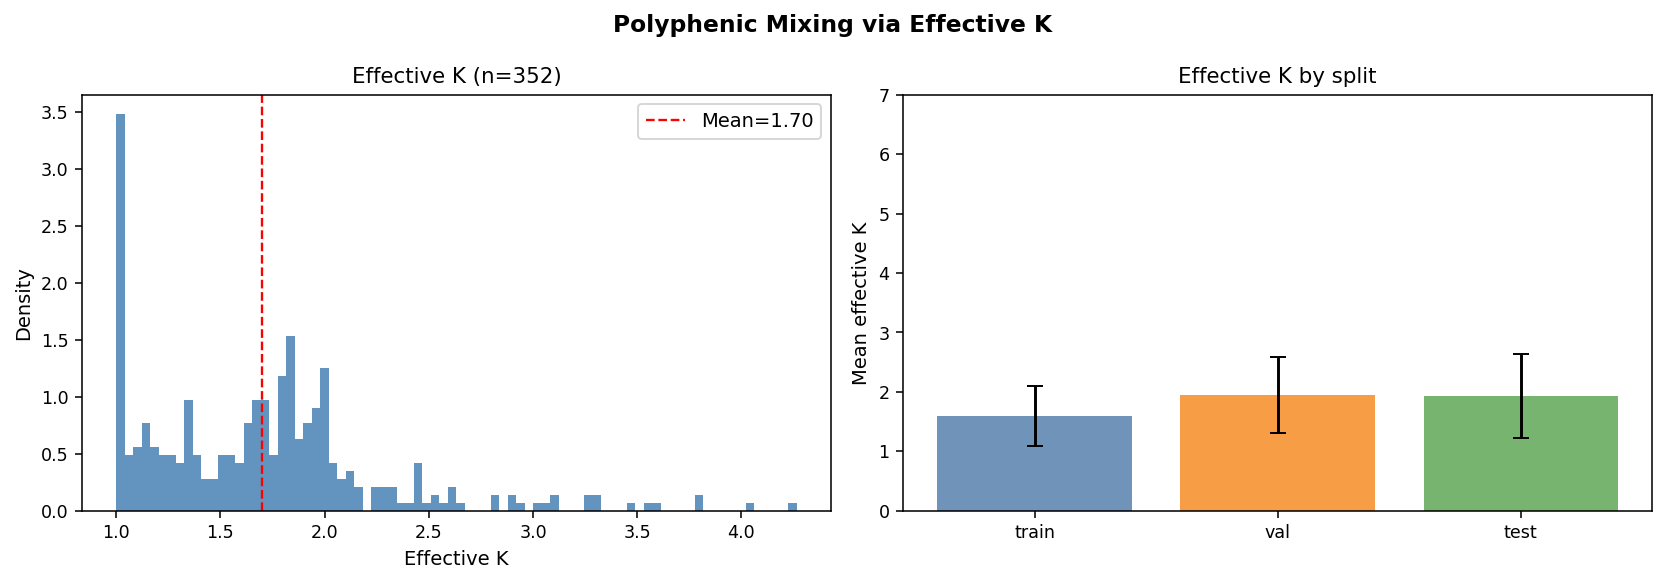

Mean effective K: 1.698
Saved fig6


In [59]:
# Figure 6: Effective K
eff = adata_sub.obs['effective_k'].to_numpy(dtype=float)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].hist(eff, bins=80, color='steelblue', alpha=0.85, density=True)
axes[0].axvline(eff.mean(), color='red', ls='--', lw=1.2, label=f'Mean={eff.mean():.2f}')
axes[0].set_xlabel('Effective K')
axes[0].set_ylabel('Density')
axes[0].set_title(f'Effective K (n={len(eff):,})')
axes[0].legend()

by_split = adata_sub.obs.groupby('split')['effective_k'].agg(['mean', 'std']).reindex(['train', 'val', 'test'])
axes[1].bar(range(len(by_split)), by_split['mean'].values, yerr=by_split['std'].fillna(0).values,
            capsize=4, color=['#4c78a8', '#f58518', '#54a24b'], alpha=0.8)
axes[1].set_xticks(range(len(by_split)))
axes[1].set_xticklabels(by_split.index)
axes[1].set_ylabel('Mean effective K')
axes[1].set_ylim(0, max(1.05 * by_split['mean'].max(), float(K)))
axes[1].set_title('Effective K by split')

fig.suptitle('Polyphenic Mixing via Effective K', fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig6_effective_k.png')
fig.savefig(FIG_DIR / 'fig6_effective_k.pdf')
plt.show()
print(f'Mean effective K: {eff.mean():.3f}')
print('Saved fig6')



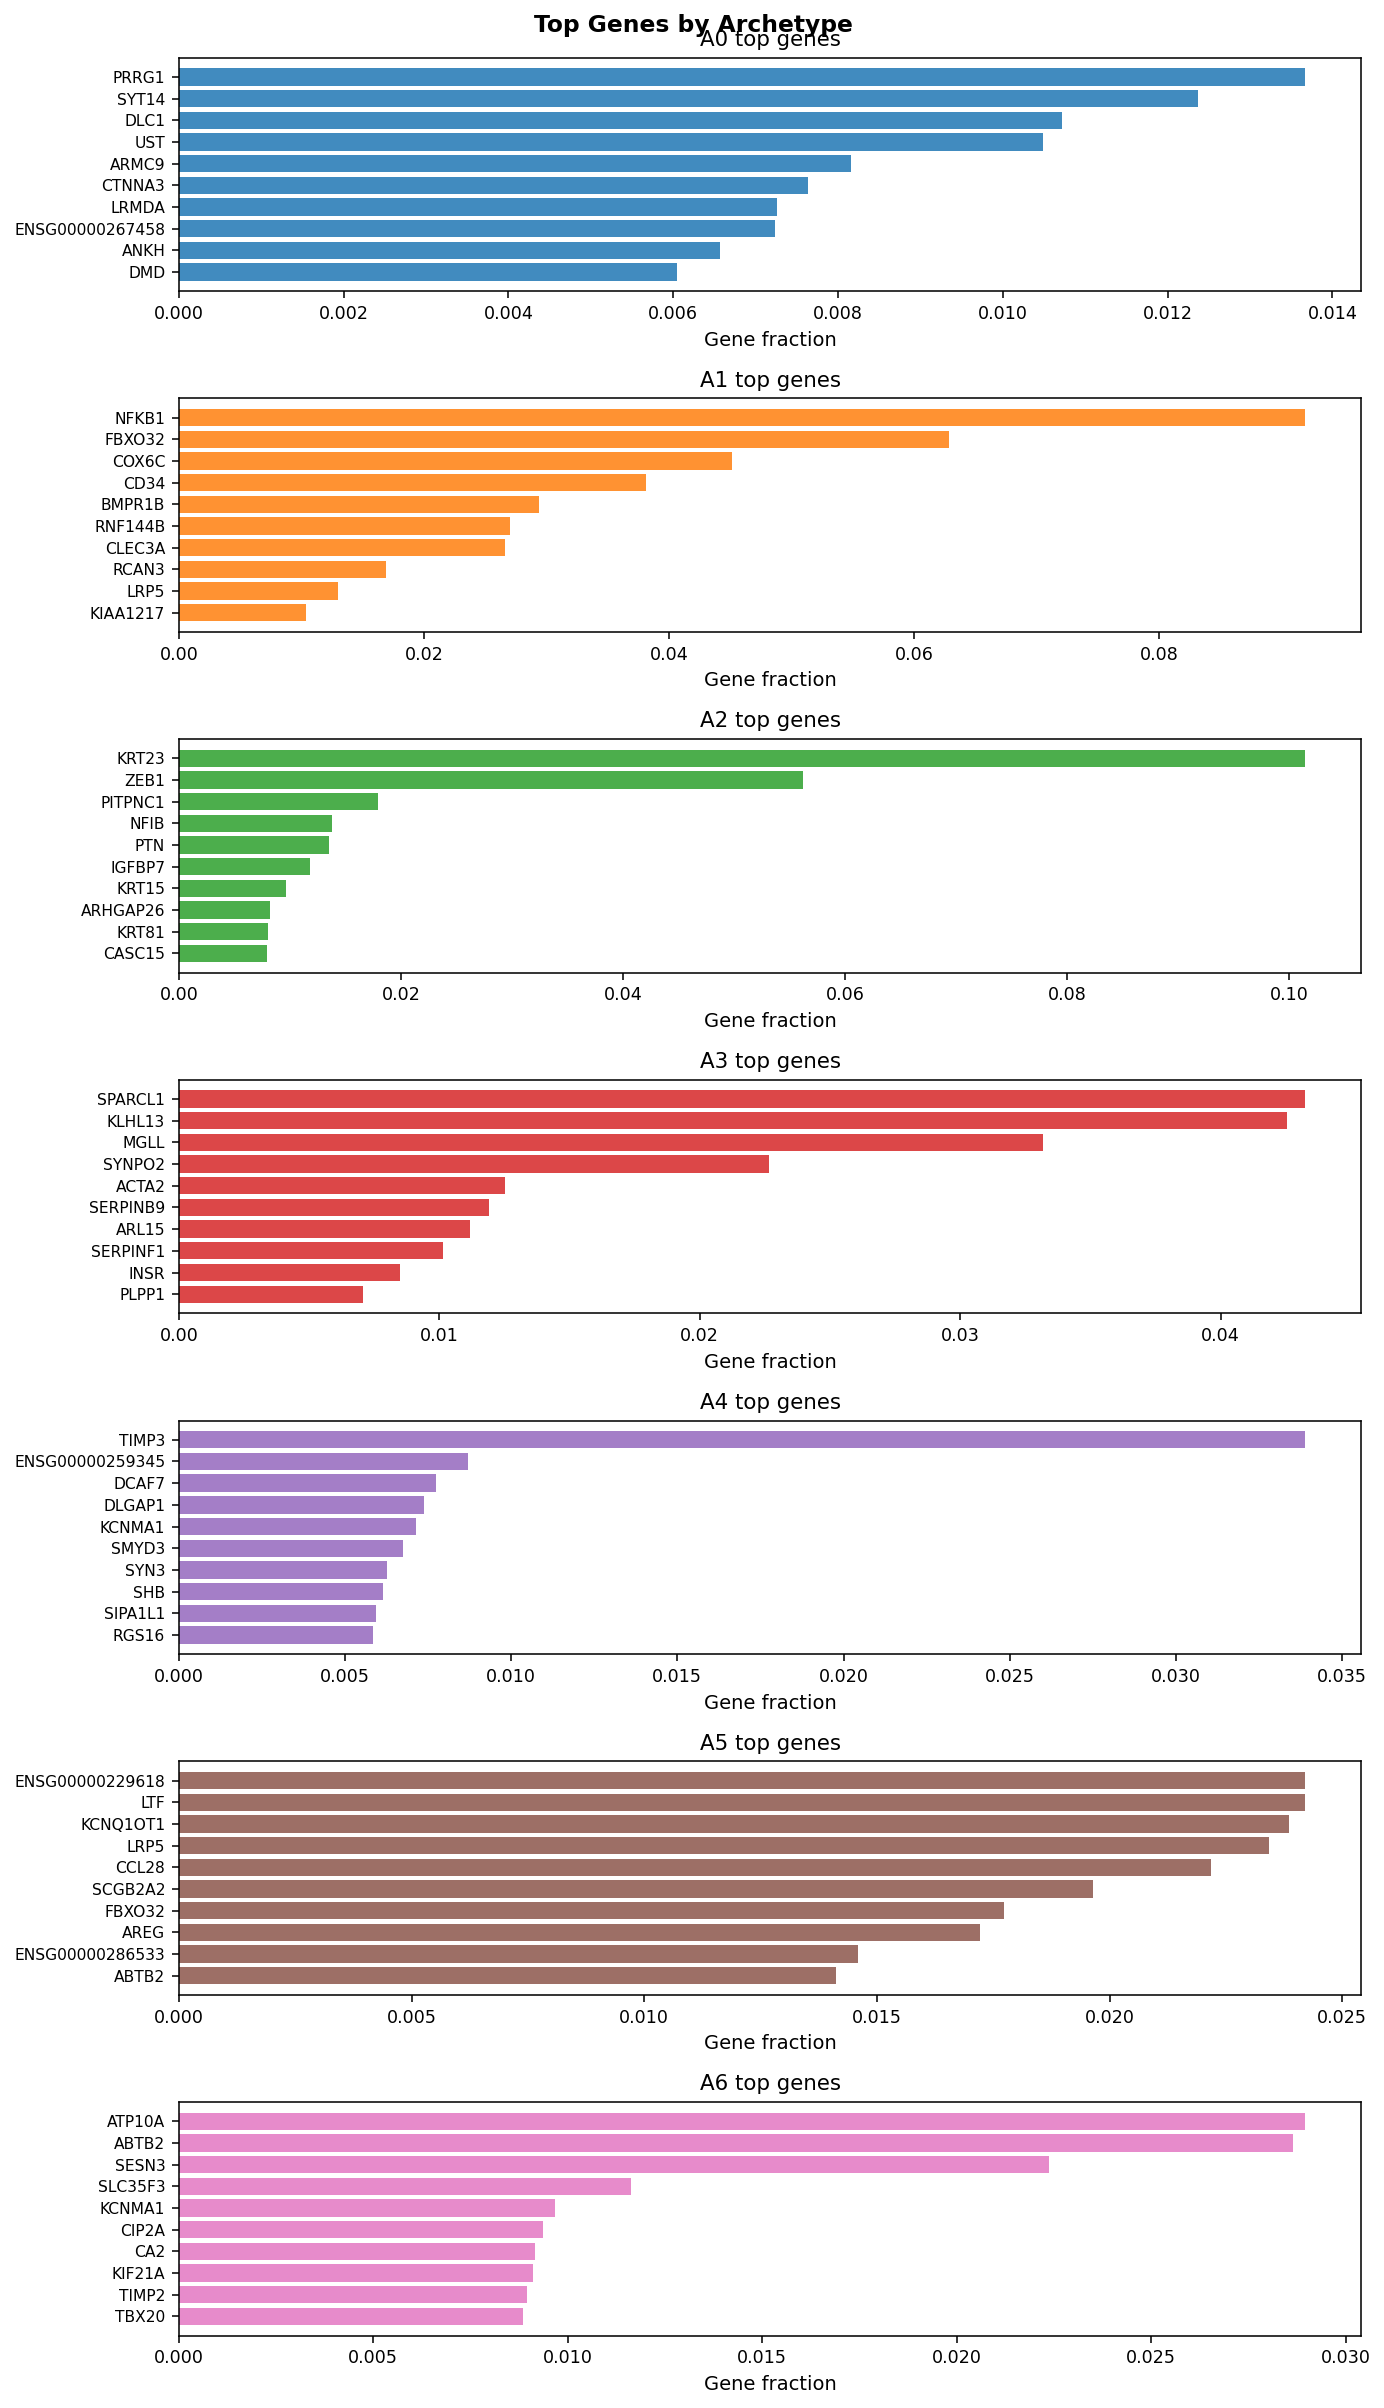

Saved fig7


In [60]:
# Figure 7: Top genes per archetype (horizontal bars)
fig, axes = plt.subplots(K, 1, figsize=(10, max(2.5 * K, 6)), sharex=False)
if K == 1:
    axes = [axes]

for i, arch in enumerate(COMP_NAMES):
    top = fractions.loc[arch].sort_values(ascending=False).head(10)
    axes[i].barh(np.arange(len(top))[::-1], top.values, color=palette[i], alpha=0.85)
    axes[i].set_yticks(np.arange(len(top))[::-1])
    axes[i].set_yticklabels(top.index, fontsize=8)
    axes[i].set_xlabel('Gene fraction')
    axes[i].set_title(f'{arch} top genes')

fig.suptitle('Top Genes by Archetype', fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig7_top_genes.png')
fig.savefig(FIG_DIR / 'fig7_top_genes.pdf')
plt.show()
print('Saved fig7')



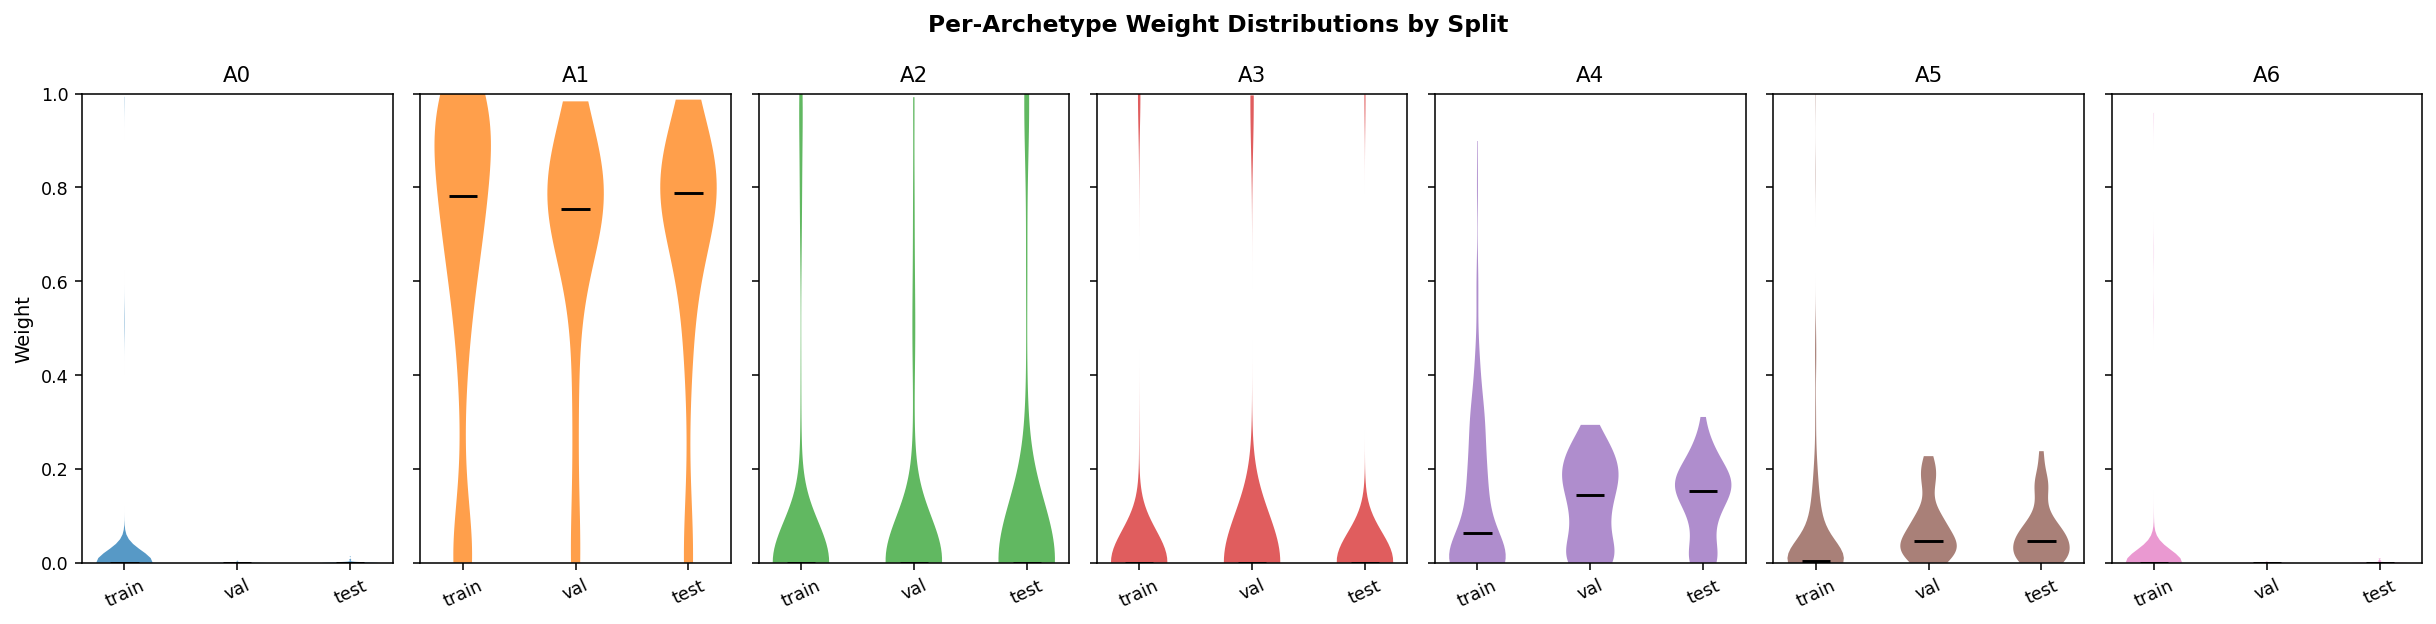

Saved fig8


In [61]:
# Figure 8: Weight distributions by split (violin)
fig, axes = plt.subplots(1, K, figsize=(max(12, 2.5 * K), 4.5), sharey=True)
if K == 1:
    axes = [axes]

for i, comp_col in enumerate(W_COLS):
    ax = axes[i]
    data = [
        adata_sub.obs.loc[adata_sub.obs['split'] == s, comp_col].to_numpy(dtype=float)
        for s in ['train', 'val', 'test']
    ]
    vp = ax.violinplot(data, positions=[0, 1, 2], showmedians=True, showextrema=False)
    for body in vp['bodies']:
        body.set_facecolor(palette[i])
        body.set_alpha(0.75)
    vp['cmedians'].set_color('black')
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['train', 'val', 'test'], rotation=25)
    ax.set_title(f'A{i}')
    ax.set_ylim(0, 1)
    if i == 0:
        ax.set_ylabel('Weight')

fig.suptitle('Per-Archetype Weight Distributions by Split', fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig8_weight_distributions.png')
fig.savefig(FIG_DIR / 'fig8_weight_distributions.pdf')
plt.show()
print('Saved fig8')



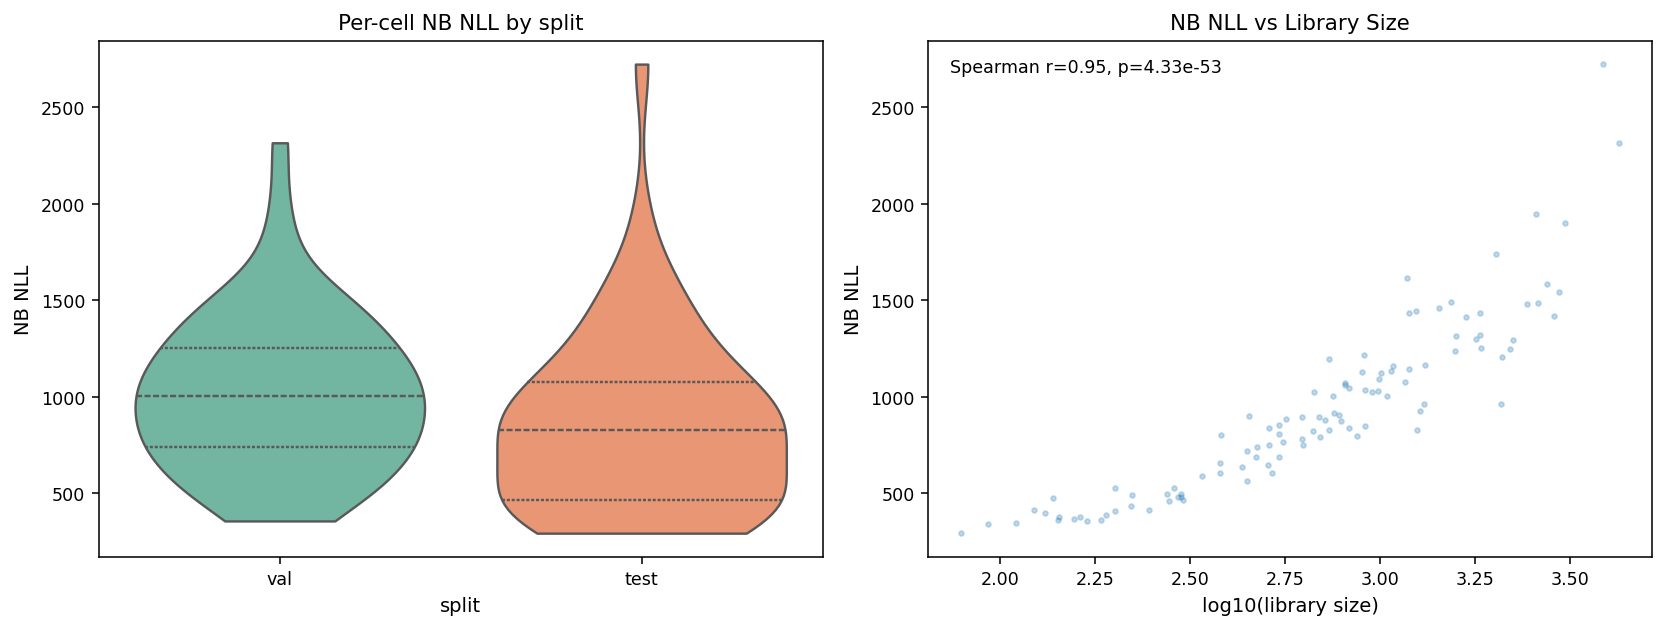

Saved fig9


In [62]:
# Figure 9: NB per-cell reconstruction diagnostics (val/test)
per_cell_frames = []
for split in ['val', 'test']:
    p = RUN_DIR / 'metrics' / f'{split}_per_cell_loss.csv'
    if p.exists():
        df = pd.read_csv(p)
        df['split'] = split
        per_cell_frames.append(df)

if len(per_cell_frames) == 0:
    print('No per-cell NB diagnostics found; skipping fig9.')
else:
    per_cell = pd.concat(per_cell_frames, ignore_index=True)

    # library size from h5ad aligned cells
    if sparse.issparse(adata_sub.X):
        libsize = np.asarray(adata_sub.X.sum(axis=1)).ravel()
    else:
        libsize = np.asarray(adata_sub.X.sum(axis=1)).ravel()
    lib_map = pd.Series(libsize, index=adata_sub.obs['cell_id'].astype(str)).to_dict()
    per_cell['library_size'] = per_cell['cell_id'].astype(str).map(lib_map)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

    sns.violinplot(data=per_cell, x='split', y='nb_nll', ax=axes[0], inner='quartile', palette='Set2', cut=0)
    axes[0].set_title('Per-cell NB NLL by split')
    axes[0].set_ylabel('NB NLL')

    x = np.log10(np.clip(per_cell['library_size'].to_numpy(dtype=float), 1, None))
    y = per_cell['nb_nll'].to_numpy(dtype=float)
    axes[1].scatter(x, y, s=6, alpha=0.25, color='tab:blue')
    if np.isfinite(x).sum() > 10 and np.isfinite(y).sum() > 10:
        r, p = spearmanr(x, y)
        axes[1].text(0.03, 0.94, f'Spearman r={r:.2f}, p={p:.2e}', transform=axes[1].transAxes, fontsize=9)
    axes[1].set_xlabel('log10(library size)')
    axes[1].set_ylabel('NB NLL')
    axes[1].set_title('NB NLL vs Library Size')

    plt.tight_layout()
    fig.savefig(FIG_DIR / 'fig9_nb_diagnostics.png')
    fig.savefig(FIG_DIR / 'fig9_nb_diagnostics.pdf')
    plt.show()
    print('Saved fig9')



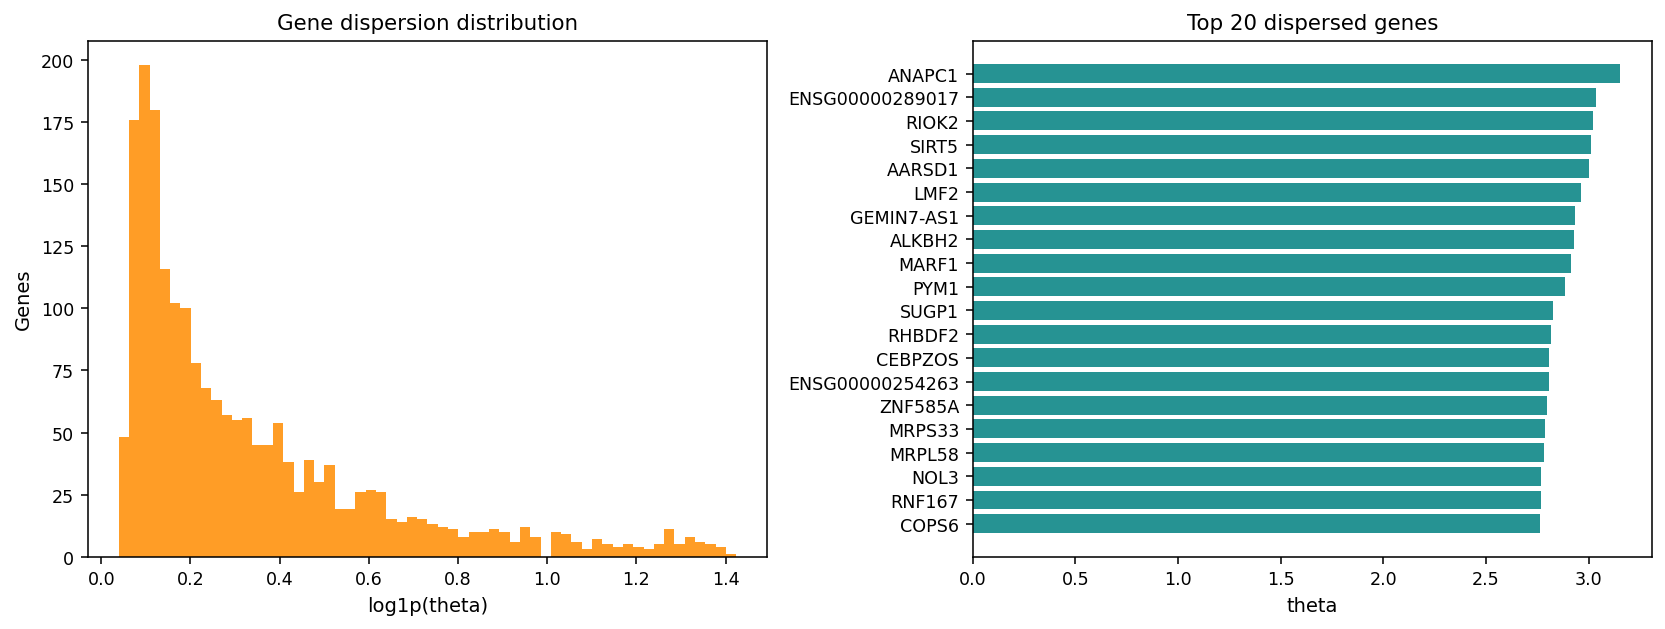

Saved fig10


In [63]:
# Figure 10: Gene dispersion summary
th = theta_df.copy()
th = th.sort_values('theta', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

axes[0].hist(np.log1p(th['theta'].values), bins=60, color='darkorange', alpha=0.85)
axes[0].set_xlabel('log1p(theta)')
axes[0].set_ylabel('Genes')
axes[0].set_title('Gene dispersion distribution')

n_top = 20
top = th.head(n_top).iloc[::-1]
axes[1].barh(top['gene'], top['theta'], color='teal', alpha=0.85)
axes[1].set_xlabel('theta')
axes[1].set_title(f'Top {n_top} dispersed genes')

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig10_gene_dispersion.png')
fig.savefig(FIG_DIR / 'fig10_gene_dispersion.pdf')
plt.show()
print('Saved fig10')



## Step 8 - Bootstrap Stability and Sample Sufficiency

This section quantifies whether the current cell count is enough for stable archetype estimates:
- Bootstrap CI of mean archetype weights
- Bootstrap reproducibility of archetype gene profiles (Spearman vs full-data profile)
- Bootstrap CI of mean effective K


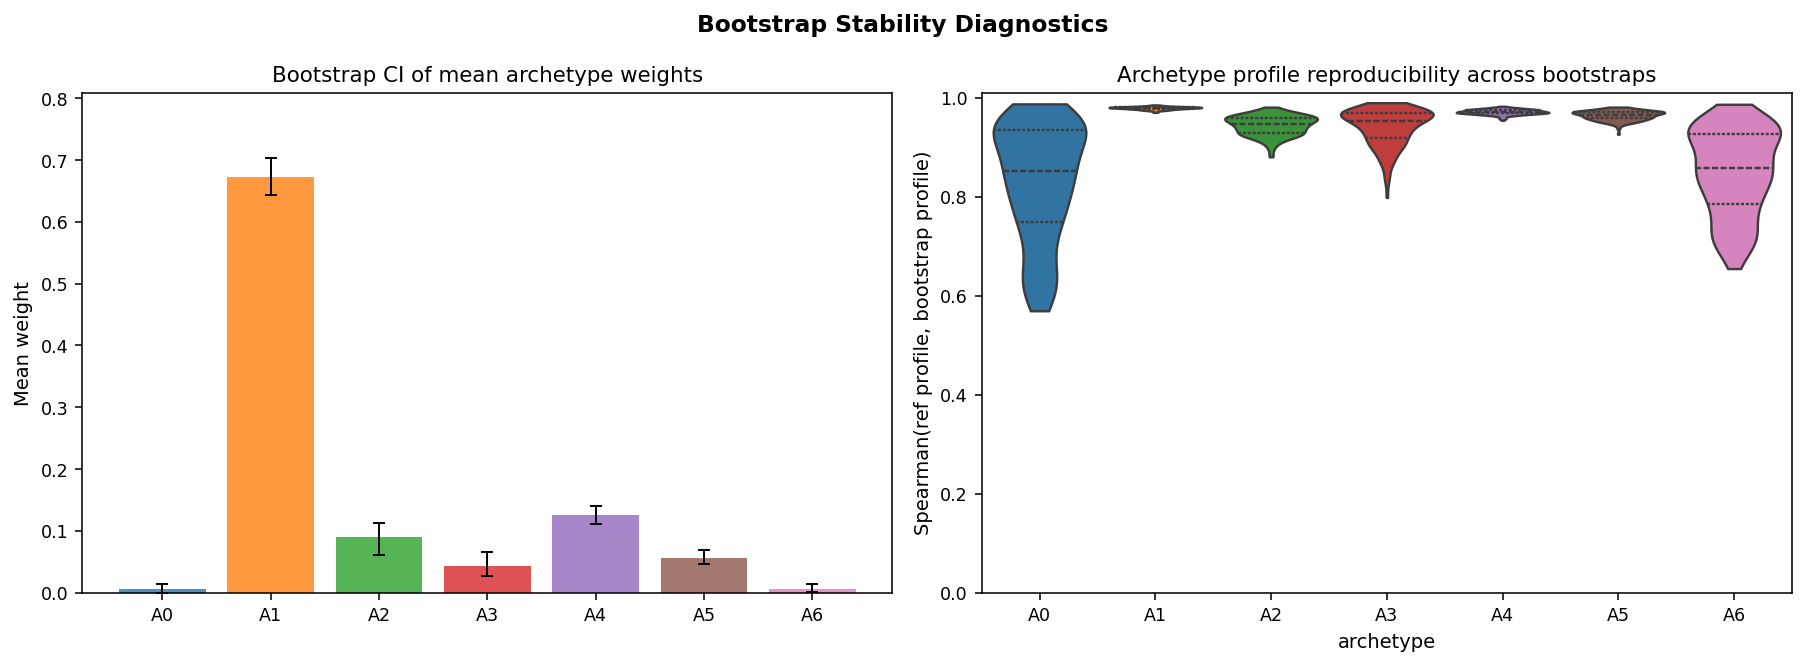

Saved fig11
Saved: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/reports/bck44_nb_k7/bootstrap_archetype_stability.csv
Saved: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/reports/bck44_nb_k7/bootstrap_global_stability.csv

Global bootstrap summary:


,n_cells_aligned,n_boot,mean_effective_k_orig,mean_effective_k_ci_low,mean_effective_k_ci_high,median_profile_spearman_across_arch
0,352,150,1.6979,1.6356,1.7566,0.9526



Archetype bootstrap summary:


,archetype,mean_weight_orig,mean_weight_ci_low,mean_weight_ci_high,mean_weight_ci_width,profile_spearman_median,profile_spearman_p05,profile_spearman_p95
0,A1,0.6729,0.6431,0.7035,0.0604,0.9796,0.9744,0.9831
1,A4,0.1256,0.1112,0.1403,0.0290,0.9709,0.9637,0.9787
2,A2,0.0893,0.0617,0.1131,0.0514,0.9466,0.9104,0.9713
3,A5,0.0560,0.0470,0.0688,0.0219,0.9657,0.9485,0.9775
4,A3,0.0438,0.0262,0.0657,0.0395,0.9526,0.8717,0.9809
5,A6,0.0065,0.0006,0.0138,0.0132,0.8587,0.7020,0.9567
6,A0,0.0059,0.0001,0.0142,0.0141,0.8527,0.6072,0.9610


In [64]:
# Figure 11: Bootstrap stability diagnostics
N_BOOT = 150
BOOT_SAMPLE_FRAC = 1.0   # fraction of cells per bootstrap sample
BOOT_RANDOM_SEED = 42

rng = np.random.default_rng(BOOT_RANDOM_SEED)

W_mat = adata_sub.obs[W_COLS].to_numpy(dtype=np.float32)
X_mat = adata_sub.X
n_cells = int(adata_sub.n_obs)
n_draw = max(200, int(round(n_cells * BOOT_SAMPLE_FRAC)))

if n_cells < 500:
    print(f'Warning: only {n_cells} cells aligned; bootstrap estimates may be noisy.')

# Reference archetype profiles on full aligned data
# profile_k(g) = sum_i w_ik * x_ig / sum_i w_ik
_eps = 1e-8
if sparse.issparse(X_mat):
    ref_profiles = np.vstack([
        np.asarray(X_mat.T.dot(W_mat[:, k])).ravel() / (float(W_mat[:, k].sum()) + _eps)
        for k in range(K)
    ]).astype(np.float32)
else:
    Xd = np.asarray(X_mat, dtype=np.float32)
    ref_profiles = np.vstack([
        (W_mat[:, k] @ Xd) / (float(W_mat[:, k].sum()) + _eps)
        for k in range(K)
    ]).astype(np.float32)

boot_mean_w = np.zeros((N_BOOT, K), dtype=np.float32)
boot_effk = np.zeros(N_BOOT, dtype=np.float32)
boot_prof_corr = np.full((N_BOOT, K), np.nan, dtype=np.float32)

for b in range(N_BOOT):
    idx = rng.integers(0, n_cells, size=n_draw)
    Wb = W_mat[idx, :]
    Xb = X_mat[idx, :] if sparse.issparse(X_mat) else np.asarray(X_mat[idx, :], dtype=np.float32)

    boot_mean_w[b, :] = Wb.mean(axis=0)

    ent_b = -(np.clip(Wb, 1e-12, 1.0) * np.log(np.clip(Wb, 1e-12, 1.0))).sum(axis=1)
    boot_effk[b] = float(np.exp(ent_b).mean())

    for k in range(K):
        wk = Wb[:, k]
        denom = float(wk.sum()) + _eps
        if sparse.issparse(Xb):
            prof_k = np.asarray(Xb.T.dot(wk)).ravel() / denom
        else:
            prof_k = (wk @ Xb) / denom

        r, _ = spearmanr(ref_profiles[k], prof_k)
        if np.isfinite(r):
            boot_prof_corr[b, k] = float(r)

mean_w_orig = W_mat.mean(axis=0)
mean_w_lo = np.quantile(boot_mean_w, 0.025, axis=0)
mean_w_hi = np.quantile(boot_mean_w, 0.975, axis=0)

boot_summary_df = pd.DataFrame({
    'archetype': COMP_NAMES,
    'mean_weight_orig': mean_w_orig,
    'mean_weight_ci_low': mean_w_lo,
    'mean_weight_ci_high': mean_w_hi,
    'mean_weight_ci_width': mean_w_hi - mean_w_lo,
    'profile_spearman_median': np.nanmedian(boot_prof_corr, axis=0),
    'profile_spearman_p05': np.nanquantile(boot_prof_corr, 0.05, axis=0),
    'profile_spearman_p95': np.nanquantile(boot_prof_corr, 0.95, axis=0),
}).sort_values('mean_weight_orig', ascending=False).reset_index(drop=True)

boot_global_summary_df = pd.DataFrame([{
    'n_cells_aligned': n_cells,
    'n_boot': N_BOOT,
    'mean_effective_k_orig': float(np.exp(-(np.clip(W_mat, 1e-12, 1.0) * np.log(np.clip(W_mat, 1e-12, 1.0))).sum(axis=1)).mean()),
    'mean_effective_k_ci_low': float(np.quantile(boot_effk, 0.025)),
    'mean_effective_k_ci_high': float(np.quantile(boot_effk, 0.975)),
    'median_profile_spearman_across_arch': float(np.nanmedian(boot_summary_df['profile_spearman_median'])),
}])

# Plot Figure 11
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
pal = sns.color_palette('tab10', K)

order = np.arange(K)
means = np.array([boot_summary_df.loc[boot_summary_df['archetype'] == f'A{i}', 'mean_weight_orig'].iloc[0] for i in range(K)])
los = np.array([boot_summary_df.loc[boot_summary_df['archetype'] == f'A{i}', 'mean_weight_ci_low'].iloc[0] for i in range(K)])
his = np.array([boot_summary_df.loc[boot_summary_df['archetype'] == f'A{i}', 'mean_weight_ci_high'].iloc[0] for i in range(K)])
yerr = np.vstack([means - los, his - means])

axes[0].bar(order, means, color=pal, alpha=0.8)
axes[0].errorbar(order, means, yerr=yerr, fmt='none', ecolor='black', elinewidth=1.0, capsize=3)
axes[0].set_xticks(order)
axes[0].set_xticklabels([f'A{i}' for i in range(K)])
axes[0].set_ylim(0, min(1.0, max(0.25, float((his.max() * 1.15)))))
axes[0].set_ylabel('Mean weight')
axes[0].set_title('Bootstrap CI of mean archetype weights')

corr_long = pd.DataFrame(boot_prof_corr, columns=COMP_NAMES).melt(var_name='archetype', value_name='spearman')
sns.violinplot(data=corr_long, x='archetype', y='spearman', ax=axes[1], inner='quartile', palette=pal, cut=0)
axes[1].set_ylim(0, 1.01)
axes[1].set_ylabel('Spearman(ref profile, bootstrap profile)')
axes[1].set_title('Archetype profile reproducibility across bootstraps')

fig.suptitle('Bootstrap Stability Diagnostics', fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig11_bootstrap_stability.png')
fig.savefig(FIG_DIR / 'fig11_bootstrap_stability.pdf')
plt.show()

# Save tables
boot_summary_path = OUT_DIR / 'bootstrap_archetype_stability.csv'
boot_global_path = OUT_DIR / 'bootstrap_global_stability.csv'
boot_summary_df.to_csv(boot_summary_path, index=False)
boot_global_summary_df.to_csv(boot_global_path, index=False)

print('Saved fig11')
print('Saved:', boot_summary_path)
print('Saved:', boot_global_path)
print('\nGlobal bootstrap summary:')
display(boot_global_summary_df.round(4))
print('\nArchetype bootstrap summary:')
display(boot_summary_df.round(4))



## Step 9 - External Signature Matching (H5Seurat)

This section matches external signature scores (for example, UCell scores) from the Seurat object to the aligned cells used in this notebook, for the selected K run.

Outputs:
- signature-weight Spearman correlations
- mean signature value by dominant archetype
- correlation heatmap (for report)



Aligned cells with signatures: 319 / 352 weighted cells


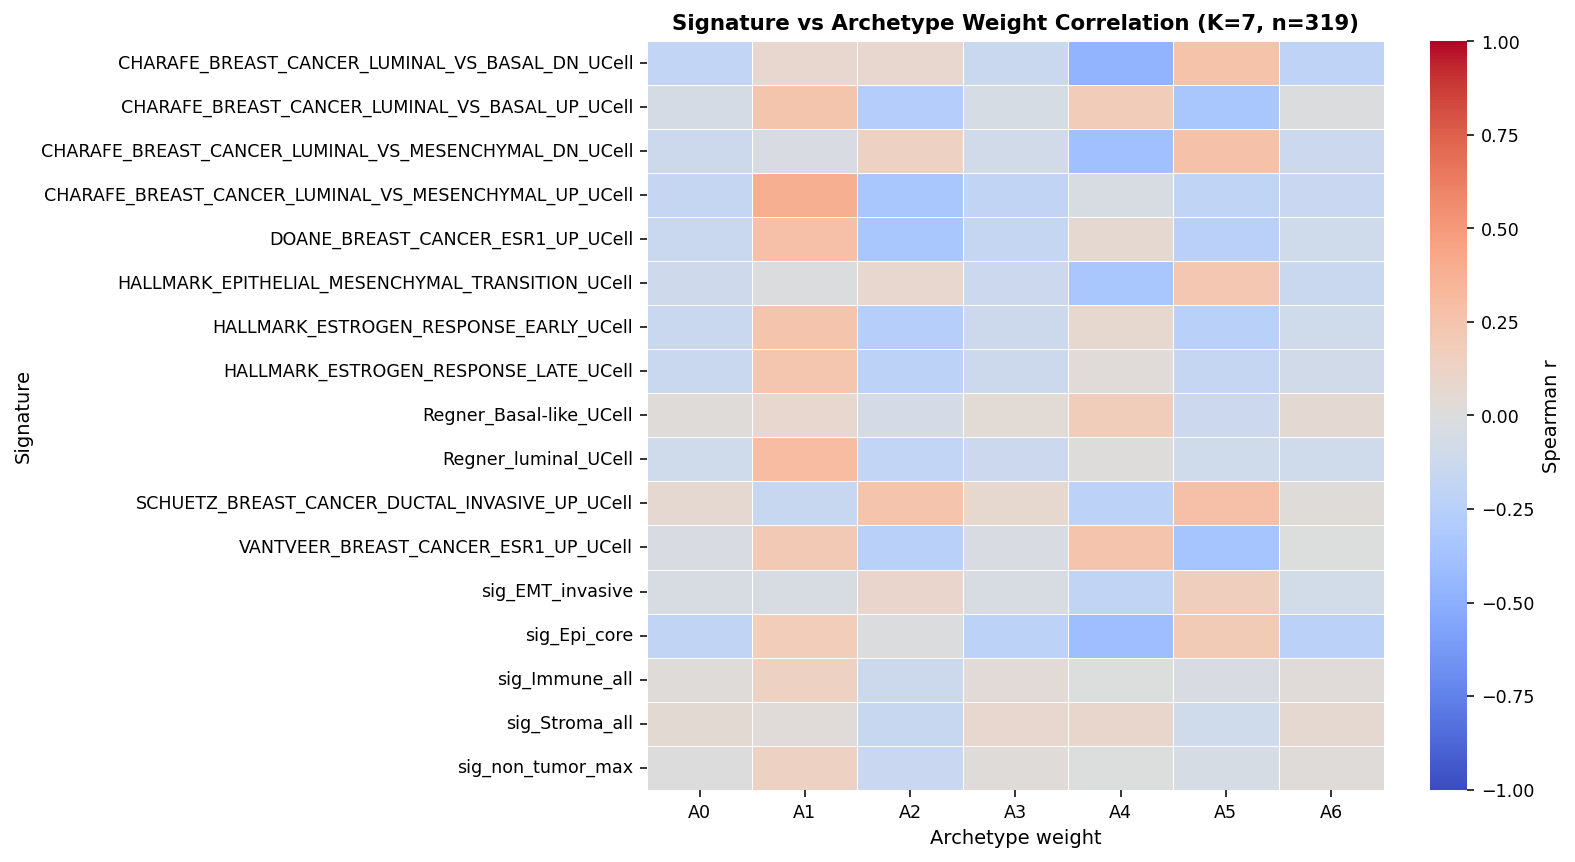

Saved: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/reports/bck44_nb_k7/bck44_nb_k7_signature_weight_spearman.csv
Saved: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/reports/bck44_nb_k7/bck44_nb_k7_signature_by_dominant.csv

Top signature-weight associations by |rho|:


,signature,archetype,rho_spearman,p_value,n_cells,q_value_bh,abs_rho
0,CHARAFE_BREAST_CANCER_LUMINAL_VS_BASAL_DN_UCell,A4,-0.4707,0.0,319,0.0000,0.4707
1,sig_Epi_core,A4,-0.3988,0.0,319,0.0000,0.3988
2,CHARAFE_BREAST_CANCER_LUMINAL_VS_MESENCHYMAL_U...,A1,0.3899,0.0,319,0.0000,0.3899
3,CHARAFE_BREAST_CANCER_LUMINAL_VS_MESENCHYMAL_D...,A4,-0.3871,0.0,319,0.0000,0.3871
4,VANTVEER_BREAST_CANCER_ESR1_UP_UCell,A5,-0.3582,0.0,319,0.0000,0.3582
5,CHARAFE_BREAST_CANCER_LUMINAL_VS_MESENCHYMAL_U...,A2,-0.3388,0.0,319,0.0000,0.3388
6,HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION_UCell,A4,-0.3318,0.0,319,0.0000,0.3318
7,DOANE_BREAST_CANCER_ESR1_UP_UCell,A2,-0.3316,0.0,319,0.0000,0.3316
8,CHARAFE_BREAST_CANCER_LUMINAL_VS_BASAL_UP_UCell,A5,-0.3291,0.0,319,0.0000,0.3291
9,Regner_luminal_UCell,A1,0.3107,0.0,319,0.0000,0.3107


In [65]:
# Figure 12: Match Seurat signatures to archetype weights (dynamic K)
sig_corr_df = None
sig_by_dom_df = None
sig_merged_df = None

if not H5SEURAT_SIGNATURE_PATH.exists():
    print(f'Signature file not found, skipping: {H5SEURAT_SIGNATURE_PATH}')
else:
    def _decode_obj(arr):
        out = []
        for x in arr:
            if isinstance(x, (bytes, np.bytes_)):
                out.append(x.decode('utf-8'))
            else:
                out.append(str(x))
        return np.array(out, dtype=object)

    with h5py.File(H5SEURAT_SIGNATURE_PATH, 'r') as f:
        if 'meta.data' not in f:
            raise RuntimeError('H5Seurat has no meta.data group')
        md = f['meta.data']

        if '_index' in md:
            cell_ids = _decode_obj(md['_index'][()])
        elif 'cell' in md:
            cell_ids = _decode_obj(md['cell'][()])
        elif 'cell.names' in f:
            cell_ids = _decode_obj(f['cell.names'][()])
        else:
            raise RuntimeError('Could not find cell IDs in H5Seurat (meta.data/_index, meta.data/cell, or cell.names).')

        sig_frame = pd.DataFrame({'cell_id': cell_ids.astype(str)})
        sig_cols = []
        for key in md.keys():
            if key in {'_index', 'cell'}:
                continue
            obj = md[key]
            if not isinstance(obj, h5py.Dataset):
                continue
            if len(obj.shape) != 1 or obj.shape[0] != len(cell_ids):
                continue
            vals = obj[()]
            if np.issubdtype(vals.dtype, np.number):
                sig_frame[key] = vals.astype(np.float64)
                sig_cols.append(key)

    sig_cols = [c for c in sig_cols if re.search(SIGNATURE_REGEX, c) is not None]
    if len(sig_cols) == 0:
        print(f'No signature columns matched regex: {SIGNATURE_REGEX}')
    else:
        # Drop near-constant signature columns
        keep = []
        for c in sig_cols:
            v = sig_frame[c].to_numpy(dtype=float)
            if np.isfinite(v).sum() < 10:
                continue
            if float(np.nanstd(v)) < 1e-10:
                continue
            keep.append(c)
        sig_cols = keep

        if len(sig_cols) == 0:
            print('All matched signature columns were near-constant or invalid.')
        else:
            sig_merged_df = merged[['cell_id', 'dominant_name', *W_COLS]].merge(
                sig_frame[['cell_id', *sig_cols]], on='cell_id', how='inner'
            )
            n_aligned_sig = int(len(sig_merged_df))
            print(f'Aligned cells with signatures: {n_aligned_sig:,} / {len(merged):,} weighted cells')

            if n_aligned_sig < 30:
                print('Too few aligned cells for robust correlation analysis; skipping figure/table generation.')
            else:
                rows = []
                for sig in sig_cols:
                    x = sig_merged_df[sig].to_numpy(dtype=float)
                    for j, wcol in enumerate(W_COLS):
                        y = sig_merged_df[wcol].to_numpy(dtype=float)
                        rho, p = spearmanr(x, y)
                        rows.append({
                            'signature': sig,
                            'archetype': f'A{j}',
                            'rho_spearman': float(rho) if np.isfinite(rho) else np.nan,
                            'p_value': float(p) if np.isfinite(p) else np.nan,
                            'n_cells': n_aligned_sig,
                        })

                sig_corr_df = pd.DataFrame(rows)

                # FDR correction (BH)
                pvals = sig_corr_df['p_value'].to_numpy(dtype=float)
                finite = np.isfinite(pvals)
                qvals = np.full_like(pvals, np.nan, dtype=float)
                if finite.any():
                    p = pvals[finite]
                    order = np.argsort(p)
                    ranked = p[order]
                    m = len(ranked)
                    q = ranked * m / (np.arange(m) + 1)
                    q = np.minimum.accumulate(q[::-1])[::-1]
                    q = np.clip(q, 0.0, 1.0)
                    q_back = np.empty_like(q)
                    q_back[order] = q
                    qvals[finite] = q_back
                sig_corr_df['q_value_bh'] = qvals
                sig_corr_df['abs_rho'] = sig_corr_df['rho_spearman'].abs()
                sig_corr_df = sig_corr_df.sort_values(['abs_rho', 'p_value'], ascending=[False, True]).reset_index(drop=True)

                sig_by_dom_df = (
                    sig_merged_df.groupby('dominant_name')[sig_cols]
                    .mean()
                    .T
                    .reset_index()
                    .rename(columns={'index': 'signature'})
                )

                corr_pivot = sig_corr_df.pivot(index='signature', columns='archetype', values='rho_spearman')
                if len(corr_pivot) > MAX_SIGNATURES_HEATMAP:
                    top_sigs = (
                        sig_corr_df.groupby('signature')['abs_rho']
                        .max()
                        .sort_values(ascending=False)
                        .head(MAX_SIGNATURES_HEATMAP)
                        .index
                        .tolist()
                    )
                    corr_pivot = corr_pivot.loc[top_sigs]

                fig_h = max(4.0, 0.28 * len(corr_pivot) + 1.5)
                fig, ax = plt.subplots(1, 1, figsize=(1.2 * K + 3.0, fig_h))
                sns.heatmap(
                    corr_pivot,
                    ax=ax,
                    cmap='coolwarm',
                    vmin=-1,
                    vmax=1,
                    center=0,
                    linewidths=0.35,
                    linecolor='white',
                    cbar_kws={'label': 'Spearman r'},
                )
                ax.set_title(f'Signature vs Archetype Weight Correlation (K={K}, n={n_aligned_sig})', fontweight='bold')
                ax.set_xlabel('Archetype weight')
                ax.set_ylabel('Signature')
                plt.tight_layout()
                fig.savefig(FIG_DIR / 'fig12_signature_weight_correlations.png')
                fig.savefig(FIG_DIR / 'fig12_signature_weight_correlations.pdf')
                plt.show()

                sig_corr_path = OUT_DIR / f'bck44_nb_k{K}_signature_weight_spearman.csv'
                sig_by_dom_path = OUT_DIR / f'bck44_nb_k{K}_signature_by_dominant.csv'
                sig_corr_df.to_csv(sig_corr_path, index=False)
                sig_by_dom_df.to_csv(sig_by_dom_path, index=False)
                print('Saved:', sig_corr_path)
                print('Saved:', sig_by_dom_path)

                print('')
                print('Top signature-weight associations by |rho|:')
                display(sig_corr_df.head(20).round(4))



In [66]:
# Generate markdown + optional PDF report

n_cells = int(adata_sub.n_obs)
n_genes = int(adata_sub.n_vars)
mean_eff = float(adata_sub.obs['effective_k'].mean())
poly_frac = float((adata_sub.obs['effective_k'] >= 1.5).mean())
best_val = float(hist[BEST_COL].min())
best_epoch = int(hist[BEST_COL].idxmin())

split_tbl = (
    adata_sub.obs.groupby('split')[W_COLS + ['effective_k']]
    .mean()
    .rename(columns={f'w_{i}': f'A{i}' for i in range(K)})
)

lines = []
lines.append('---')
lines.append(f'title: "BCK_44 scRNA NB Archetype Analysis (K={K}, seed={SEED})"')
lines.append('author: "Guy Ron"')
lines.append('date: "April 2026"')
lines.append('geometry: margin=2.5cm')
lines.append('fontsize: 10pt')
lines.append('linestretch: 1.15')
lines.append('---')
lines.append('')
lines.append('# Summary')
lines.append('')
lines.append(
    f'This report analyzes the selected NB-PAE sweep run for BCK_44 scRNA-seq: '
    f'K={K}, seed={SEED}, best {BEST_COL}={best_val:.4f} at epoch {best_epoch}. '
    f'The aligned dataset includes {n_cells:,} cells and {n_genes:,} HVGs.'
)
lines.append('')
lines.append(
    f'Mean effective K is {mean_eff:.2f}, with {poly_frac:.1%} of cells showing polyphenic mixing '
    f'(effective K >= 1.5).'
)
lines.append('')
lines.append('# Mean Composition by Split')
lines.append('')
lines.append(split_tbl.round(3).to_markdown())
lines.append('')

if 'boot_global_summary_df' in globals() and 'boot_summary_df' in globals():
    lines.append('# Bootstrap Stability')
    lines.append('')
    lines.append(boot_global_summary_df.round(3).to_markdown(index=False))
    lines.append('')
    cols = ['archetype', 'mean_weight_orig', 'mean_weight_ci_low', 'mean_weight_ci_high', 'profile_spearman_median']
    lines.append(boot_summary_df[cols].round(3).to_markdown(index=False))
    lines.append('')


if 'sig_corr_df' in globals() and sig_corr_df is not None and len(sig_corr_df) > 0:
    lines.append('# External Signature Matching')
    lines.append('')
    lines.append(
        'External signature scores from the H5Seurat object were aligned to the weighted cells and '
        'correlated with archetype weights (Spearman).'
    )
    lines.append('')
    top_sig = sig_corr_df[['signature', 'archetype', 'rho_spearman', 'p_value', 'q_value_bh']].head(20)
    lines.append(top_sig.round(3).to_markdown(index=False))
    lines.append('')

lines.append('# Figures')
lines.append('')
for i, caption in [
    (1, 'Archetype top-gene fraction heatmap'),
    (2, 'Training convergence'),
    (3, 'UMAP composition'),
    (4, 'Composition by split'),
    (5, 'Weight pairwise relationships'),
    (6, 'Effective K distribution'),
    (7, 'Top genes per archetype'),
    (8, 'Weight distributions by split'),
    (9, 'NB reconstruction diagnostics'),
    (10, 'Gene dispersion summary'),
    (11, 'Bootstrap stability diagnostics'),
    (12, 'Signature-weight correlations'),
]:
    png_files = sorted(FIG_DIR.glob(f'fig{i}_*.png'))
    png_rel = f"figures/{png_files[0].name}" if len(png_files) > 0 else None
    if png_rel is None:
        continue
    lines.append(f'## Figure {i}: {caption}')
    lines.append('')
    lines.append(f'![Figure {i}]({png_rel})')
    lines.append('')

report_md = OUT_DIR / 'report.md'
report_pdf = OUT_DIR / 'report.pdf'
OUT_DIR.mkdir(parents=True, exist_ok=True)
report_md.write_text('\n'.join(lines), encoding='utf-8')
print('Wrote markdown report:', report_md)

try:
    cmd = ['pandoc', str(report_md), '-o', str(report_pdf)]
    subprocess.run(cmd, check=True, capture_output=True, text=True)
    print('Wrote PDF report:', report_pdf)
except Exception as e:
    print('PDF generation skipped (pandoc unavailable or failed):', e)





Wrote markdown report: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/reports/bck44_nb_k7/report.md
Wrote PDF report: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/reports/bck44_nb_k7/report.pdf
